In [1]:
# do install if needed. for example for collab runs
#!pip install -r decision-making-exam/requirements.txt


## Data Loading and Preprocessing

The data is recoded to have 8 arms based on the displayed amounts. The original 6-choice task had different stakes (low, medium, high). These can optionally be collapsed into 8 unique arms.

In [ ]:
import sys
sys.path.insert(0, '..')  # Add parent dir for imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import jax
import arviz as az
from numpyro.infer import NUTS, MCMC, Predictive
from pvl_delta import pvl_delta_model, inv_probit
import jax.numpy as jnp

# Set number of CPU cores for parallel chains
import numpyro


# Configuration
n_arms = 6  # 6 or 8 are valid. 8 will recode data based on displayed amounts

# Test mode: set to number of subjects per group for quick testing, or None for full data
test_n_per_group = None  # Set to None for full dataset

reward_scaling = False

# Prior scale for PVL-Delta model
# - 1.0: Standard weakly informative priors (default)
# - 0.5: 2x tighter
# - 0.1: 10x tighter  
# - 0.01: 100x tighter (very strong regularization)
# - 2.0: 2x wider
prior_scale = 0.01

/Users/emilfrej/Documents/7 semester/decisionmaking/decision-making-exam/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_full = pd.read_csv("../data/decmakdata.csv")

# Keep only relevant columns
df = df_full[["phase", "amount", "outcome", "choice", "condition", "group", "subject"]]

# Filter for experiment only, and win/loss outcomes to avoid signal trials and missed RTs
df = df.loc[df["phase"] == "experi"]
df = df.loc[df["outcome"].isin(["win", "loss"])]

# Subset subjects for testing if test_n_per_group is set
if test_n_per_group is not None:
    rng = np.random.default_rng(seed=42)  
    stop_subjects = df[df['group'] == 'bSTOP']['subject'].unique()[:test_n_per_group]
    double_subjects = df[df['group'] == 'bDOUBLE']['subject'].unique()[:test_n_per_group]
    selected_subjects = np.concatenate([stop_subjects, double_subjects])
    df = df[df['subject'].isin(selected_subjects)]
    print(f"TEST MODE: Using {test_n_per_group} subjects per group ({len(selected_subjects)} total)")

# Code new "displayed amount" column
# On losses, they lost half of the displayed amount; on wins they gained the displayed amount
df["displayed_amount"] = df["amount"].where(df["amount"] > 0, df["amount"] * -2)

# Shift rewards to be non-negative for the utility function
df["reward_scaled"] = (df["amount"] / df["amount"].max())

# Code new arm from displayed amount column (0 is highest outcome arm, 7 is lowest)
mapping = {value: i for i, value in enumerate(sorted(df["displayed_amount"].unique(), reverse=True))}
df["arm"] = df["displayed_amount"].map(mapping)

print(f"Number of subjects: {df['subject'].nunique()}")
print(f"Trials per subject: ~{len(df) // df['subject'].nunique()}")
print(f"\nGroup distribution:")
print(df.groupby('subject')['group'].first().value_counts())
print(mapping)

df.sample(10)

Number of subjects: 64
Trials per subject: ~231

Group distribution:
group
bSTOP      32
bDOUBLE    32
Name: count, dtype: int64
{np.int64(256): 0, np.int64(128): 1, np.int64(64): 2, np.int64(32): 3, np.int64(16): 4, np.int64(8): 5, np.int64(4): 6, np.int64(2): 7}


,phase,amount,outcome,choice,condition,group,subject,displayed_amount,reward_scaled,arm
19919,experi,32,win,3,noload,bDOUBLE,62,32,0.125000,3
15651,experi,8,win,5,load,bDOUBLE,37,8,0.031250,5
2648,experi,8,win,5,load,bSTOP,25,8,0.031250,5
3933,experi,-8,loss,4,noload,bSTOP,35,16,-0.031250,4
3405,experi,8,win,6,noload,bSTOP,27,8,0.031250,5
9296,experi,-32,loss,3,noload,bSTOP,61,64,-0.125000,2
8941,experi,64,win,3,load,bSTOP,6,64,0.250000,2
537,experi,-8,loss,5,noload,bSTOP,11,16,-0.031250,4
9552,experi,2,win,6,load,bSTOP,63,2,0.007812,7
13205,experi,-32,loss,1,noload,bDOUBLE,20,64,-0.125000,2


In [4]:
# Prepare data arrays for each subject
subj_arrays = []
subj_trial_202 = []

for subj in sorted(df["subject"].unique()):
    subj_df = df.loc[df["subject"] == subj].iloc[:202]  # First 202 trials
    trial_202 = subj_df.iloc[-1]
    subj_df = df.loc[df["subject"] == subj].iloc[:201]

    #get choice depeing on 6/8 arm config
    if n_arms == 8:
        choice_array = subj_df["arm"].to_numpy()
        choice_202 = trial_202["arm"]
    else:
        choice_array = subj_df["choice"].to_numpy() - 1  # Convert to 0-indexed
        choice_202 = trial_202["choice"] - 1

    #get reward depending on scaling is true or not 
    if reward_scaling == True:
        reward_array = subj_df["reward_scaled"].to_numpy()
        reward_202 = trial_202["reward_scaled"]
    else:
        reward_array = subj_df["amount"].to_numpy()
        reward_202 = trial_202["amount"]
        #stopcition
    stop_condition = subj_df["group"].iloc[0] == "bSTOP"
    stop_202 = trial_202["group"] == "bSTOP"
    # Indicates whether a load block was presented on each trial
    load_block_array = (subj_df["condition"] == "load").to_numpy()
    load_block_202 = trial_202["condition"] == "load"

    subj_arrays.append({
        "subject": subj,
        "choice_array": choice_array,
        "reward_array": reward_array,
        "stop_condition": stop_condition,
        "load_block_array": load_block_array,
        "test_choice": choice_202
    })

    subj_trial_202.append({
        "subject": subj,
        "choice": choice_202,
        "reward": reward_202,
        "stop_condition": stop_202,
        "load_block": load_block_202
    })

# Setup data for PVL fit
choices = np.column_stack([d["choice_array"] for d in subj_arrays])
rewards = np.column_stack([d["reward_array"] for d in subj_arrays])
# Shape: (n_trials, n_subjects) - whether each subject was in a load block on each trial
load_blocks = np.column_stack([d["load_block_array"] for d in subj_arrays])
stop_condition = np.array([d["stop_condition"] for d in subj_arrays])
n_subjects = len(stop_condition)

print(f"Data shape: {choices.shape[0]} trials x {n_subjects} subjects")
print(f"Stop condition subjects: {stop_condition.sum()} / {n_subjects}")
print(f"Load block trials: {load_blocks.sum()} / {load_blocks.size}")
print(f"Reward range: [{rewards.min():.1f}, {rewards.max():.1f}]")



Data shape: 201 trials x 64 subjects
Stop condition subjects: 32 / 64
Load block trials: 5051 / 12864
Reward range: [-128.0, 256.0]


## Model Fitting

setup sampling below

In [ ]:
# MCMC configuration
NUM_WARMUP = 3000
NUM_SAMPLES = 1000
NUM_CHAINS = 2

print(f"Running MCMC with {NUM_CHAINS} chains, {NUM_WARMUP} warmup, {NUM_SAMPLES} samples each")
print(f"Total posterior samples: {NUM_CHAINS * NUM_SAMPLES}")

Running MCMC with 1 chains, 3000 warmup, 1000 samples each
Total posterior samples: 1000


In [6]:
from pathlib import Path
from numpyro.infer.reparam import LocScaleReparam

# Build filename that captures all relevant settings
test_suffix = f"_test{test_n_per_group}" if test_n_per_group else ""
prior_suffix = f"_prior_scale_{str(prior_scale).replace('.', 'p')}" if prior_scale != 1.0 else ""
filename = Path(f"../fitted_models/inference_data_{n_arms}_arms_{NUM_CHAINS}_chains_{NUM_SAMPLES}_samples_{NUM_WARMUP}warmup{test_suffix}_reward_scaling_{str(reward_scaling)}{prior_suffix}.nc")

# Ensure fitted_models directory exists
filename.parent.mkdir(parents=True, exist_ok=True)

rng_key = jax.random.key(42)

if filename.exists():
    print(f"{filename.name} exists. Skipping MCMC and loading it")
    idata = az.from_netcdf(filename)
else:
    print(f"No matching fit found. Running MCMC...")
    print(f"  Arms: {n_arms}, Chains: {NUM_CHAINS}, Samples: {NUM_SAMPLES}, Warmup: {NUM_WARMUP}")
    print(f"  Prior scale: {prior_scale}")
    with numpyro.validation_enabled():
        config = {
            "probit_lr": LocScaleReparam(centered=0),
            "probit_inv_t": LocScaleReparam(centered=0),
            "probit_u_shape": LocScaleReparam(centered=0),
            "probit_u_aversion": LocScaleReparam(centered=0),
        }
        reparam_model = numpyro.handlers.reparam(pvl_delta_model, config=config)
        nuts_kernel = NUTS(
            reparam_model,
            target_accept_prob=0.8,
            max_tree_depth=10,
        )
        mcmc = MCMC(
            nuts_kernel,
            num_samples=NUM_SAMPLES,
            num_warmup=NUM_WARMUP,
            num_chains=NUM_CHAINS,
        )
        key, subkey = jax.random.split(rng_key)

        mcmc.run(
            subkey,
            choices=choices,
            rewards=rewards,
            stop_condition=stop_condition,
            n_arms=n_arms,
            n_subjects=n_subjects,
            load_blocks=load_blocks,
            prior_scale=prior_scale,
        )

    # Convert to ArviZ InferenceData (automatically includes log_likelihood)
    idata = az.from_numpyro(mcmc)
    
    # Generate posterior predictive samples
    predictive = Predictive(reparam_model, mcmc.get_samples())
    ppc_key = jax.random.key(0)
    posterior_predictive = predictive(
        ppc_key,
        choices=choices,
        rewards=rewards,
        stop_condition=stop_condition,
        load_blocks=load_blocks,
        n_arms=n_arms,
        n_subjects=n_subjects,
        prior_scale=prior_scale,
    )

    # Adding posterior predictive to InferenceData
    idata.extend(az.from_numpyro(posterior_predictive=posterior_predictive))

    # Save it
    az.to_netcdf(idata, filename)
    print(f"Saved to {filename.name}")
    
print(f"idata groups: {list(idata.groups())}")

inference_data_6_arms_1_chains_1000_samples_3000warmup_reward_scaling_False_prior_scale_0p05.nc exists. Skipping MCMC and loading it
idata groups: ['posterior', 'posterior_predictive', 'log_likelihood', 'sample_stats', 'observed_data']


## Baseline Model Fitting

We fit a Dirichlet-Categorical baseline model that learns choice frequencies per subject. This model does not incorporate reward learning - it simply estimates each subject's probability distribution over arms based on their empirical choice frequencies. This provides a comparison point for the PVL-Delta model via Bayesian model comparison (LOO, WAIC).

In [ ]:
from pvl_delta.baseline_model import baseline_model
#3 min to run for 1 chain
#make function to trace probs
def baseline_probs_trajectory(probs_sample, choices, alpha=1.0):
    n_trials, n_subjects = choices.shape
    n_arms = probs_sample.shape[1]
    counts = jnp.ones((n_subjects, n_arms)) * alpha
    probs_traj = []

    for t in range(n_trials):
        probs_traj.append(counts / counts.sum(axis=1, keepdims=True))
        counts = counts.at[jnp.arange(n_subjects), choices[t]].add(1)

    return jnp.stack(probs_traj, axis=0)

# Build filename for baseline model
baseline_filename = Path(f"../fitted_models/baseline_inference_data_{n_arms}_arms_{NUM_CHAINS}_chains_{NUM_SAMPLES}_samples_{NUM_WARMUP}warmup{test_suffix}_reward_scaling_{str(reward_scaling)}.nc")

if baseline_filename.exists():
    print(f"{baseline_filename.name} exists. Skipping MCMC and loading it")
    baseline_idata = az.from_netcdf(baseline_filename)
else:
    print(f"No matching baseline fit found. Running MCMC...")
    print(f"  Arms: {n_arms}, Chains: {NUM_CHAINS}, Samples: {NUM_SAMPLES}, Warmup: {NUM_WARMUP}")
    
    baseline_nuts_kernel = NUTS(
        baseline_model,
        target_accept_prob=0.8,
        max_tree_depth=10,
    )
    baseline_mcmc = MCMC(
        baseline_nuts_kernel,
        num_samples=NUM_SAMPLES,
        num_warmup=NUM_WARMUP,
        num_chains=NUM_CHAINS,
    )
    
    baseline_key = jax.random.key(43)  # Different seed from main model
    
    baseline_mcmc.run(
        baseline_key,
        n_arms=n_arms,
        n_subjects=n_subjects,
        choices=choices,
    )
    

    
    # Generate posterior predictive samples
    baseline_predictive = Predictive(baseline_model, baseline_mcmc.get_samples())
    baseline_ppc_key = jax.random.key(1)
    baseline_posterior_predictive = baseline_predictive(
        baseline_ppc_key,
        n_arms=n_arms,
        n_subjects=n_subjects,
        choices=choices,
    )
    posterior_samples = baseline_mcmc.get_samples()
    traj_list = []
    for i in range(len(posterior_samples["alpha"])):
        alpha_i = posterior_samples["alpha"][i]
        probs_i = posterior_samples["probs"][i]  # shape (n_subjects, n_arms)
        traj = baseline_probs_trajectory(probs_i, choices, alpha_i)
        traj_list.append(traj)
    traj_array = jnp.stack(traj_list) 
    baseline_idata = az.from_dict(posterior={"probs_traj": traj_array})
    
    # Add posterior predictive to InferenceData
    baseline_idata.extend(az.from_numpyro(posterior_predictive=baseline_posterior_predictive))
    
    # Save it
    az.to_netcdf(baseline_idata, baseline_filename)
    print(f"Saved baseline model to {baseline_filename.name}")

print(f"baseline_idata groups: {list(baseline_idata.groups())}")

No matching baseline fit found. Running MCMC...
  Arms: 6, Chains: 1, Samples: 1000, Warmup: 3000


sample: 100%|██████████| 4000/4000 [00:21<00:00, 189.18it/s, 15 steps of size 2.87e-01. acc. prob=0.87]
/Users/emilfrej/Documents/7 semester/decisionmaking/decision-making-exam/.venv/lib/python3.11/site-packages/arviz/data/base.py:272: UserWarning: More chains (1000) than draws (201). Passed array should have shape (chains, draws, *shape)
  warnings.warn(


Saved baseline model to baseline_inference_data_6_arms_1_chains_1000_samples_3000warmup_reward_scaling_False.nc
baseline_idata groups: ['posterior', 'posterior_predictive']


In [ ]:
# Baseline model diagnostics
print("BASELINE MODEL PARAMETER SUMMARY")
baseline_summary = az.summary(baseline_idata)
print(baseline_summary.head(10).to_string())  # Show first 10 rows (alpha + some probs)

# Divergences
baseline_divergent = baseline_idata.sample_stats.diverging.sum().item()
print(f"\nBaseline model divergences: {baseline_divergent}")

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


BASELINE MODEL PARAMETER SUMMARY
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
alpha  0.844  0.064   0.735    0.973      0.003    0.002     413.0     477.0    NaN

Baseline model divergences: 0


## Model Comparison (LOO)

Compare the PVL-Delta model against the baseline frequency-counting model using Leave-One-Out cross-validation (LOO-CV). Lower ELPD indicates better predictive performance.

Computing LOO for PVL-Delta model...


/Users/emilfrej/Documents/7 semester/decisionmaking/decision-making-exam/.venv/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.00 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 10 posterior samples and 12864 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -65300.90  1603.86
p_loo    42193.66        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.00]   (good)         0    0.0%
   (0.00, 1]   (bad)          0    0.0%
   (1, Inf)   (very bad) 12864  100.0%


Computing LOO for Baseline model...


/Users/emilfrej/Documents/7 semester/decisionmaking/decision-making-exam/.venv/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.00 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 10 posterior samples and 12864 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -18294.16    82.96
p_loo      243.60        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.00]   (good)         0    0.0%
   (0.00, 1]   (bad)          0    0.0%
   (1, Inf)   (very bad) 12864  100.0%


MODEL COMPARISON


/Users/emilfrej/Documents/7 semester/decisionmaking/decision-making-exam/.venv/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.00 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/emilfrej/Documents/7 semester/decisionmaking/decision-making-exam/.venv/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.00 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and 

                      rank      elpd_loo         p_loo     elpd_diff  weight  \
Baseline (Frequency)     0 -18294.156052    243.604700      0.000000     1.0   
PVL-Delta                1 -65300.896320  42193.661654  47006.740268     0.0   

                               se          dse  warning scale  
Baseline (Frequency)    82.964441     0.000000     True   log  
PVL-Delta             1603.859783  1605.673943     True   log  


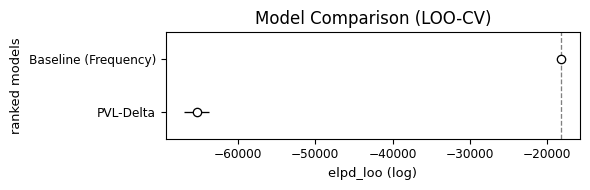

In [ ]:
# Compute LOO for both models
print("Computing LOO for PVL-Delta model...")
loo_pvl = az.loo(idata, pointwise=True)
print(loo_pvl)

print("\nComputing LOO for Baseline model...")
loo_baseline = az.loo(baseline_idata, pointwise=True)
print(loo_baseline)

# Model comparison
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
compare_dict = {"PVL-Delta": idata, "Baseline (Frequency)": baseline_idata}
comparison = az.compare(compare_dict)
print(comparison)

# Plot comparison
az.plot_compare(comparison)
plt.title("Model Comparison (LOO-CV)")
plt.tight_layout()
plt.savefig('../figures/model_comparison_loo.png', dpi=300, bbox_inches='tight')
plt.savefig('../figures/model_comparison_loo.pdf', bbox_inches='tight')
plt.show()

## Model Diagnostics


In [ ]:
# Key population-level parameters to check
pop_params = [
    'lr_loc', 'lr_scale', "interaction_lr_effect", 'stop_lr_effect', 'load_lr_effect',
    'inv_t_loc', 'inv_t_scale',"interaction_inv_t_effect", 'stop_inv_t_effect', 'load_inv_t_effect', 'interaction_inv_t_effect',
    'u_shape_loc', 'u_shape_scale', 'stop_u_shape_effect', 'load_u_shape_effect','interaction_u_shape_effect', "interaction_u_aversion_effect",
    'u_aversion_loc', 'u_aversion_scale', 'stop_u_aversion_effect', 'load_u_aversion_effect'
]

# Compute diagnostics
summary = az.summary(idata, var_names=pop_params)

# Save summary to CSV

print("POPULATION-LEVEL PARAMETER SUMMARY")

print(summary.to_string())


# Divergences
n_divergent = idata.sample_stats.diverging.sum().item()
print(f"\nDivergences: {n_divergent}")

arviz - WARNING - Shape validation failed: input_shape: (1, 10), minimum_shape: (chains=2, draws=4)


POPULATION-LEVEL PARAMETER SUMMARY
                                mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
lr_loc                         0.688  1.523  -1.809    1.653      0.798    0.339       3.0      10.0    NaN
lr_scale                       0.137  0.047   0.003    0.152      0.015    0.019       8.0      10.0    NaN
interaction_lr_effect          1.006  0.986  -0.777    1.613      0.495    0.206       3.0      10.0    NaN
stop_lr_effect                -0.490  0.416  -0.751    0.246      0.212    0.085       3.0      10.0    NaN
load_lr_effect                 1.017  1.157  -0.915    1.738      0.591    0.242       3.0      10.0    NaN
inv_t_loc                     -1.551  0.416  -2.064   -0.656      0.158    0.122       7.0      10.0    NaN
inv_t_scale                    0.277  0.153   0.012    0.402      0.083    0.031       3.0      10.0    NaN
interaction_inv_t_effect      -1.317  1.209  -2.067    0.694      0.617    0.254       3.0      10.0 

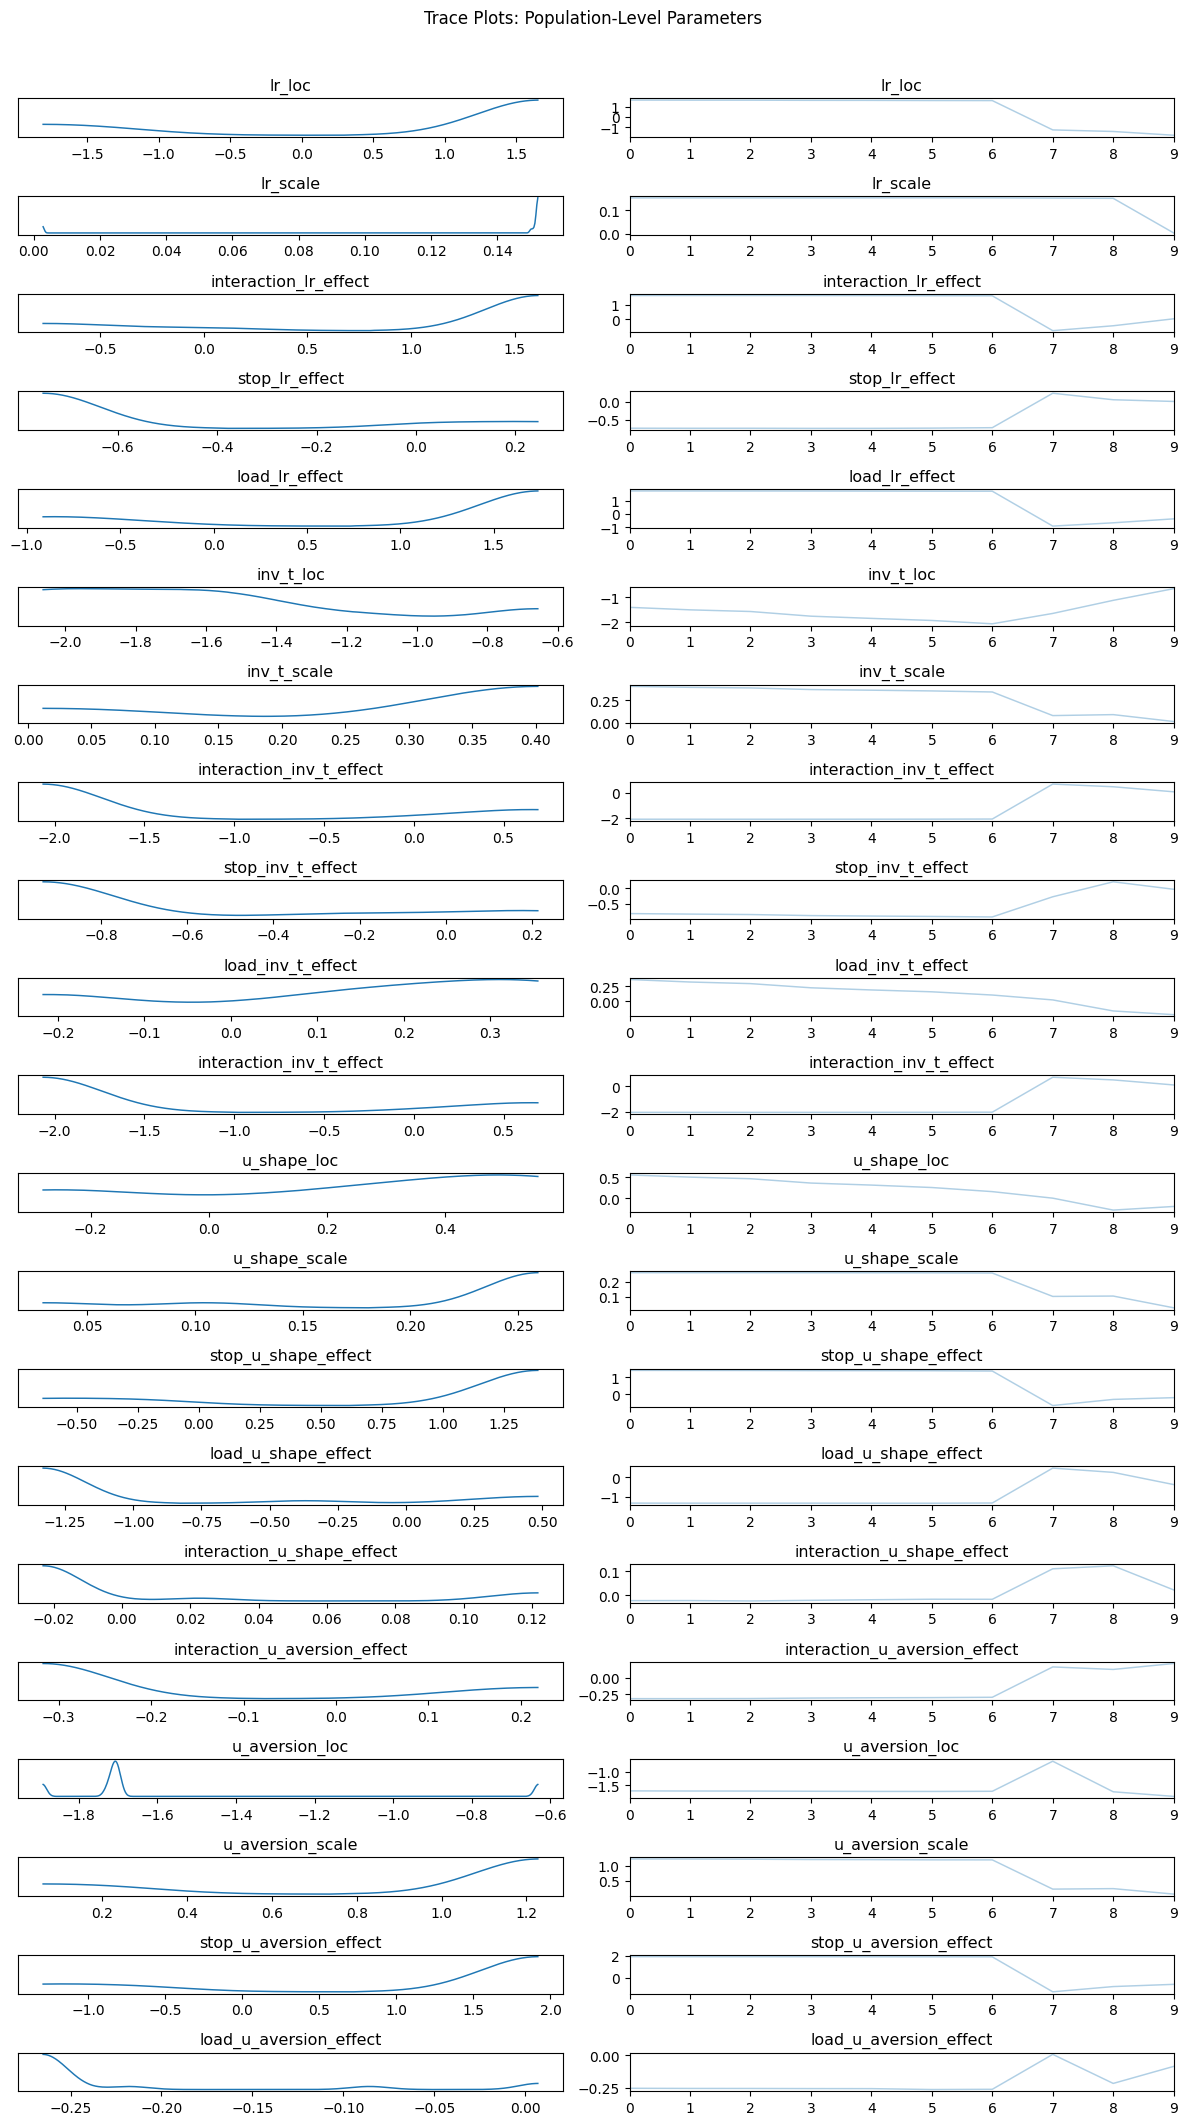

In [ ]:
# Trace plots for all population-level parameters
az.rcParams['plot.max_subplots'] = 60  # necessary to print all
axes = az.plot_trace(idata, var_names=pop_params, figsize=(12, 21))
plt.suptitle('Trace Plots: Population-Level Parameters', y=1.01)
plt.tight_layout()
plt.savefig('../figures/trace_plots_pop_params.pdf', bbox_inches='tight')
plt.savefig('../figures/trace_plots_pop_params.png', dpi=300, bbox_inches='tight')
plt.show()

## Posterior Predictive Checking

Sample from the posterior predictive distribution and evaluate model accuracy on predicting actual choices. Before anything calculate the baseline accuracy of always guessing the most frequent choice of a subject.

In [57]:
from pvl_delta import trace_qs
from scipy.stats import rankdata


mean_posterior = idata.posterior_predictive.mean(dim=["chain", "draw"])

q_pred = trace_qs(
    c=choices,
    r=rewards,
    # Initial estimate of expected values. Here we set them to zero
    q0s=np.zeros((n_subjects, n_arms)),
    lr = mean_posterior["lr"].values,
    u_aversion = mean_posterior["u_aversion"].values,
    u_shape = mean_posterior["u_shape"].values,
)

#predict all trials by picking the arm(dimension 3/axis2) with maxium utility on each trial
postdicted_choices = np.argmax(q_pred, axis = 2)

print(f"Get accuracy using q_trace() {np.mean(postdicted_choices == choices)}")


## get rank corr
#make empty array of length subjects
rhos = np.zeros(postdicted_choices.shape[1])

#then loop over and get predictions
for i in range(postdicted_choices.shape[1]):
    pred_rank = rankdata(postdicted_choices[:, i])
    obs_rank = rankdata(choices[:, i])
    rhos[i] = np.corrcoef(pred_rank, obs_rank)[0, 1]


print(f"Get mean rank predictions {np.nanmean(rhos)}")



Get accuracy using q_trace() 0.42622822523117065
Get mean rank predictions 0.19085008099674575


/Users/emilfrej/Documents/7 semester/decisionmaking/decision-making-exam/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/emilfrej/Documents/7 semester/decisionmaking/decision-making-exam/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/emilfrej/Documents/7 semester/decisionmaking/decision-making-exam/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/emilfrej/Documents/7 semester/decisionmaking/decision-making-exam/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/emilfrej/Documents/7 semester/decisionmaking/decision-making-exam/.venv/lib/python3.11/site-packages/nump

Lets do the same for the baseline model

In [56]:
from scipy.stats import rankdata


prob_samples = baseline_idata.posterior["probs_traj"].values #(1000, 201, 64, 6)
mean_probs = np.mean(prob_samples, axis = 0) #might have to update when chains are added


#predict all trials by picking the arm(dimension 3/axis2) with maxium utility on each trial
postdicted_choices = np.argmax(mean_probs, axis = 2)


print(f"Get accuracy using q_trace() {np.mean(postdicted_choices == choices)}")

postdicted_choices

# ## get rank corr
# #make empty array of length subjects
rhos = np.zeros(postdicted_choices.shape[1])

#then loop over and get predictions
for i in range(postdicted_choices.shape[1]):
    pred_rank = rankdata(postdicted_choices[:, i])
    obs_rank = rankdata(choices[:, i])
    rhos[i] = np.corrcoef(pred_rank, obs_rank)[0, 1]


print(f"Get mean rank predictions {np.nanmean(rhos)}")



Get accuracy using q_trace() 0.3870491293532338
Get mean rank predictions 0.08019476979424385


## Predict trial 202


then lets try and see what hte acc is on predicting the first trial not present in the data. Will require us to calc theta "by hand" since it depends on the condition and group of the current trial